<div style="display:flex; align-items:center; gap:18px; text-align:left">
<img src="https://sebastiancontz.github.io/ust-introduccion-machine-learning/assets/logo-ust.svg" width="100">
<div>
<p>Ingeniería en Información y Control de Gestión</p>
<p>Facultad de Economía y Negocios</p>
<p>Introducción a Machine Learning</p>
<p>Semana 01: ¿Qué es Machine Learning?</p>
</div>
</div>

# 01 · Introducción al Machine Learning

**Qué van a hacer acá:** primero terminar el taller de clasificación de casos, y después recorrer
las librerías del curso sobre un caso real de morosidad, viendo qué aporta cada una.

Este notebook tiene tres partes:

1. **El taller** — tres situaciones de gestión para encuadrar. No necesita que el código corra.
2. **El recorrido** — cargar el caso y pasar por pandas, NumPy, Matplotlib, Seaborn y scikit-learn.
3. **El cierre** — el mismo caso, encuadrado de tres maneras distintas.

Si es la primera vez que usan Colab: para ejecutar una celda, hagan clic en ella y presionen
**Shift + Enter**. Las celdas se ejecutan **en orden**; si algo falla, casi siempre es porque se
saltaron una.

## Preparación del entorno

En Colab estas librerías ya vienen instaladas, así que la celda siguiente termina en segundos. Está
igual porque el notebook también tiene que correr fuera de Colab, y porque dejar escrito de qué
depende un análisis es parte de que sea reproducible.

In [1]:
%%capture
!pip install -q pandas numpy matplotlib seaborn scikit-learn

## Cargar datos

En **Colab** los datos se leen del repo público del curso; en local, desde `../datasets/`. La misma
celda funciona en los dos casos.

In [2]:
import os
import pandas as pd

REPO = 'https://raw.githubusercontent.com/sebastiancontz/ust-introduccion-machine-learning-colab/main/introduccion-machine-learning/2026/datasets/'
BASE = '../datasets/' if os.path.exists('../datasets') else REPO

df = pd.read_csv(BASE + 'morosidad_cartera.csv')
print('Filas y columnas:', df.shape)
df.head()

Filas y columnas: (600, 8)


,id_cliente,edad,nivel_educacion,limite_credito,monto_facturado_mes,monto_pagado_mes,meses_mora,incumplio_pago
0,C-0001,36,universitaria,240000,-946,0,1,si
1,C-0002,36,universitaria,80000,79278,3100,2,no
2,C-0003,26,universitaria,50000,50867,1710,1,no
3,C-0004,31,universitaria,250000,103109,4000,0,no
4,C-0005,27,posgrado,70000,70119,3600,0,no


Son 600 clientes de crédito de consumo. Cada fila es un cliente, y la última columna dice si
**incumplió el pago del mes siguiente**. El diccionario de datos completo está en
[`datasets/README.md`](https://github.com/sebastiancontz/ust-introduccion-machine-learning-colab/blob/main/introduccion-machine-learning/2026/datasets/README.md).

> **Origen de los datos.** Adaptados de *Default of Credit Card Clients* del
> [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients),
> de Yeh, I. C. y Lien, C. H. (2009), bajo licencia
> [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). Versión modificada: submuestra de
> 600 filas y 8 columnas, traducidas y recodificadas.

---

# Parte 1 · El taller

En clase encuadramos tres casos juntos. Acá van los tres que quedan. Para cada uno, las mismas
cuatro preguntas **en orden**:

1. ¿Se puede abordar **aprendiendo de datos históricos**? Si no, ¿por qué no?
2. Si sí: ¿los datos traen la **respuesta conocida**? Con etiqueta es **supervisado**; sin etiqueta,
   **no supervisado**.
3. Si es supervisado: ¿la etiqueta es una cantidad o una categoría? **Regresión** o **clasificación**.
4. ¿Cuál sería exactamente esa etiqueta, y estaría **disponible al momento de decidir**?

Ojo con la primera: si la respuesta es *no*, el ejercicio **termina ahí**. No fuercen las otras tres.

Lo que se evalúa es la justificación, no la etiqueta que le pongan.

### Caso A

> *"Queremos anticipar cuáles de las solicitudes de crédito que aprobamos van a caer en mora en los
> próximos tres meses, para priorizar a quién le hacemos seguimiento telefónico."*

**Su respuesta** (doble clic para editar esta celda):

1.
2.
3.
4.

### Caso B

> *"Necesitamos calcular el recargo por mora que le corresponde a cada factura vencida, según lo que
> establece el contrato."*

**Su respuesta:**

1.
2.
3.
4.

### Caso C

> *"Queremos estimar cuánto va a facturar cada cliente el mes que viene, para dimensionar el equipo
> de cobranza."*

**Su respuesta:**

1.
2.
3.
4.

> **Pista para el caso C:** presten atención a la pregunta 4. Es la que más cuesta y la que más
> importa.

---

# Parte 2 · El recorrido del ecosistema

Cinco librerías, un caso. La idea no es aprender a usarlas hoy —eso es el resto del semestre— sino
ver **qué aporta cada una**.

Esta parte va en tres tiempos: primero **miramos** celdas ya resueltas, después las **revisamos
juntos** prediciendo qué va a salir antes de ejecutar, y al final hay **una para ustedes**.

<!-- Liberación gradual (interno, NO decirlo en pantalla): "Cargar y mirar" es el yo lo hago;
     "Revisémoslo juntos" es el lo hacemos, con predicción de salida y una modificación guiada;
     "Ahora ustedes" es el lo haces, con celda en blanco. -->

## Cargar y mirar

pandas es la mesa de trabajo: carga la tabla y permite inspeccionarla. Tres preguntas que uno le
hace a cualquier dataset nuevo, antes de cualquier otra cosa. Estas celdas ya están resueltas:
síganlas mientras las recorremos.

In [3]:
# ¿Qué tipo de dato tiene cada columna? ¿Falta algo?
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   id_cliente           600 non-null    str  
 1   edad                 600 non-null    int64
 2   nivel_educacion      600 non-null    str  
 3   limite_credito       600 non-null    int64
 4   monto_facturado_mes  600 non-null    int64
 5   monto_pagado_mes     600 non-null    int64
 6   meses_mora           600 non-null    int64
 7   incumplio_pago       600 non-null    str  
dtypes: int64(5), str(3)
memory usage: 37.6 KB


In [4]:
# ¿Cómo se distribuyen las columnas numéricas?
df.describe()

,edad,limite_credito,monto_facturado_mes,monto_pagado_mes,meses_mora
count,600.000000,600.000000,600.000000,600.000000,600.000000
mean,35.710000,162133.333333,48094.515000,5469.490000,0.358333
std,9.382214,125646.703282,68042.035263,12416.647104,0.751135
min,22.000000,10000.000000,-984.000000,0.000000,0.000000
25%,28.000000,50000.000000,4266.500000,997.500000,0.000000
50%,34.000000,130000.000000,20106.000000,2000.000000,0.000000
75%,42.000000,240000.000000,67056.250000,5000.000000,0.000000
max,70.000000,580000.000000,564757.000000,124174.000000,5.000000


In [5]:
# ¿Cuántos clientes incumplieron?
df['incumplio_pago'].value_counts()

incumplio_pago
no    463
si    137
Name: count, dtype: int64

**Miren la tabla de `describe()` con atención antes de seguir.**

El mínimo de `monto_facturado_mes` es **negativo**. ¿Un monto facturado negativo?

No es un error de carga: significa que el cliente tenía **saldo a favor**. Pero el punto es otro, y
es el punto de esta celda: *alguien tiene que darse cuenta*. Un modelo no se va a quejar de un valor
raro; lo va a usar igual. Mirar los datos antes de modelar es trabajo, no trámite — y es la clase 3
completa.

---

## Revisémoslo juntos

De acá en adelante, **antes de ejecutar cada celda, respondan la pregunta**. Después comparan con lo
que salió. Equivocarse acá no cuesta nada y es la forma más rápida de que algo quede.

### NumPy · calcular sobre todo a la vez

En las slides dijimos que pandas **se apoya en NumPy** por debajo. No hace falta creerlo: se puede
verificar.

La brecha entre lo facturado y lo pagado es una resta, y se aplica a las 600 filas sin ningún bucle.

> **Antes de ejecutar:** al restar dos columnas de un DataFrame, ¿qué tipo de objeto creen que
> devuelve pandas? ¿Y de qué tipo son los valores que hay dentro?

In [6]:
import numpy as np

brecha = df['monto_facturado_mes'] - df['monto_pagado_mes']

print('Tipo del objeto que devolvió pandas:', type(brecha))
print('Y por debajo, sus valores son:', type(brecha.values))
print()
# el promedio, calculado por NumPy sobre el arreglo que hay debajo de la Series
print('Brecha promedio:', round(float(np.mean(brecha.values)), 1))
print('Clientes que pagaron más de lo facturado:', int(np.sum(brecha.values < 0)))

Tipo del objeto que devolvió pandas: <class 'pandas.Series'>
Y por debajo, sus valores son: <class 'numpy.ndarray'>

Brecha promedio: 42625.0
Clientes que pagaron más de lo facturado: 93


Ahí está: pandas devolvió una `Series`, pero sus valores son un `ndarray` de **NumPy**. Esa es la
capa de abajo, haciendo el cálculo.

Eso es lo que hace que operar 600 filas —o 600 mil— sea instantáneo en vez de un bucle que hay que
esperar.

### Matplotlib y Seaborn · mirar la forma

Un número resume; un gráfico muestra la forma. La pregunta acá es concreta: **¿se ven distintos los
clientes que incumplieron de los que no?** Si no se vieran distintos en nada, no habría patrón que
aprender.

> **Antes de ejecutar:** ¿en cuál de las dos variables esperan ver más diferencia entre quienes
> incumplieron y quienes no: en el cupo de crédito o en los meses de mora? ¿Por qué?

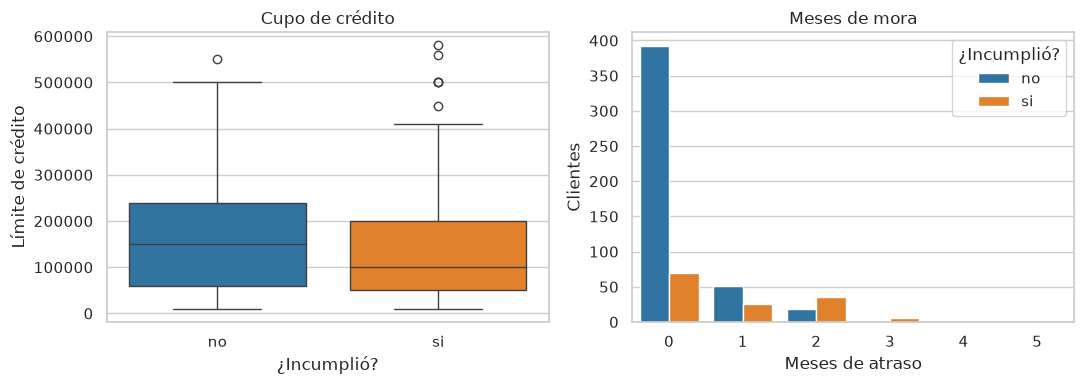

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# El color se define UNA vez, con la paleta tab10 de Tableau: los gráficos de más abajo
# la heredan sin repetir códigos de color en cada llamada.
sns.set_theme(style='whitegrid', palette='tab10')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# order y hue_order fijos en AMBOS paneles: sin esto cada gráfico asigna los
# colores según el orden de aparición del dato y el mismo valor sale de distinto
# color en cada panel, que en una figura donde el color codifica la clase se lee mal.
ORDEN = ['no', 'si']

sns.boxplot(data=df, x='incumplio_pago', y='limite_credito', ax=axes[0],
            order=ORDEN, hue='incumplio_pago', hue_order=ORDEN, legend=False)
axes[0].set_title('Cupo de crédito')
axes[0].set_xlabel('¿Incumplió?')
axes[0].set_ylabel('Límite de crédito')

sns.countplot(data=df, x='meses_mora', ax=axes[1], hue='incumplio_pago', hue_order=ORDEN)
axes[1].set_title('Meses de mora')
axes[1].set_xlabel('Meses de atraso')
axes[1].set_ylabel('Clientes')
axes[1].legend(title='¿Incumplió?')

plt.tight_layout()
plt.show()

Dos lecturas:

- A la izquierda: quienes incumplieron tienden a tener un **cupo más bajo**. Se superponen bastante,
  así que el cupo por sí solo no alcanza para decidir.
- A la derecha: **hasta dos meses de atraso** la proporción de incumplimiento sube fuerte (15 %, 33 %,
  66 %). De tres en adelante las barras casi no se ven, y eso es parte de la lección: hay 5, 2 y 2
  clientes. Con esos números no se puede leer nada — de hecho en `meses_mora = 4` ninguno incumplió.

Y una advertencia sobre cómo leer el panel derecho: muestra **conteos**, no proporciones. Las barras
altas son las de los grupos numerosos, no las de mayor riesgo. Para comparar riesgo hay que mirar la
proporción dentro de cada grupo, que es justamente lo que van a calcular más abajo.

**Ninguna de las dos cosas es una causa.** Que el cupo sea bajo no *causa* el incumplimiento: es
probable que ambos respondan a algo anterior. Es exactamente la distinción de la segunda mitad de la
clase, ahora sobre datos.

Seaborn hizo estos gráficos en pocas líneas, y por debajo usó Matplotlib. Otra vez la idea de capas.

**Prueben esto:** en la celda de arriba, cambien `limite_credito` por `monto_pagado_mes` y vuelvan a
ejecutar. ¿Se separan más o menos los dos grupos que con el cupo?

### scikit-learn · el piso contra el que comparar

Todavía no vamos a entrenar un modelo de verdad: eso arranca en la unidad 2. Pero scikit-learn tiene
algo que aportar **hoy**, y es lo primero que hay que hacer en cualquier proyecto: establecer **el
piso**.

La estrategia más tonta posible: predecir siempre lo mismo, que nadie incumple.

> **Antes de ejecutar, arriesguen un número:** ¿qué porcentaje de aciertos creen que va a tener ese
> "modelo" que no mira ninguna variable? ¿Y a cuántos morosos creen que va a detectar?

In [8]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

X = df[['edad', 'limite_credito', 'meses_mora', 'monto_facturado_mes']]
y = df['incumplio_pago']

piso = DummyClassifier(strategy='most_frequent')
piso.fit(X, y)
prediccion = piso.predict(X)

print('Exactitud del piso:', round(accuracy_score(y, prediccion), 3))
print('Morosos que detectó:', int((prediccion == 'si').sum()), 'de', int((y == 'si').sum()))

Exactitud del piso: 0.772
Morosos que detectó: 0 de 137


Ahí está la trampa del chequeo de la clase, ahora sobre nuestros datos.

Este "modelo" **no mira ninguna variable**: contesta lo mismo siempre. Y aun así acierta más de tres
de cada cuatro veces, simplemente porque la mayoría de los clientes paga. Detecta **cero** morosos,
que es justo lo único que nos importaba.

Dos cosas que se llevan de acá:

- **Una exactitud alta, sola, no dice nada.** Hay que preguntar contra qué se compara.
- **Cualquier modelo que construyamos tiene que ganarle a esto.** Si no le gana, no sirve, por más
  sofisticado que sea.

Y una advertencia honesta: esto está **incompleto a propósito**. Lo evaluamos con los mismos datos
con que lo ajustamos, y eso es exactamente lo que no hay que hacer. Falta separar una parte de los
datos para evaluar, y eso es la clase 6. Hoy quedémonos con el piso.

---

## Ahora ustedes

Una sola tarea, con lo que acabamos de ver.

**Pregunta:** ¿la proporción de incumplimiento es igual en todos los niveles de educación?

Les dejo el esqueleto. La pieza que falta es la columna por la que hay que agrupar:

```python
df.groupby('___')['incumplio_pago'].value_counts(normalize=True)
```

Escriban su versión en la celda de abajo. Si sale un error, léanlo: casi siempre dice exactamente
qué nombre no encontró.

> **Y la pregunta que importa más que el código:** si encuentran una diferencia entre niveles,
> ¿alcanza para decir que el nivel educativo **causa** el incumplimiento?

In [9]:
# Escriban acá su respuesta

Sobre la última pregunta: no, no alcanza. Encontrar que dos cosas van juntas en los datos no dice
cuál mueve a cuál, ni si hay algo detrás moviendo a las dos. Es el punto central de la clase, ahora
sobre una tabla que ustedes mismos calcularon.

---

# Parte 3 · El mismo caso, tres encuadres

Trabajamos un solo archivo. Según qué columna elijamos como respuesta, es un problema distinto:

| Si la etiqueta es… | El problema es… | La pregunta de gestión |
|:--|:--|:--|
| `incumplio_pago` | clasificación | ¿a quién le hago seguimiento? |
| `monto_facturado_mes` | regresión | ¿cuánto se va a facturar? |
| ninguna | agrupamiento | ¿qué perfiles de pago existen en la cartera? |

**Quien define la etiqueta define el problema.** Eso es la clase 2.

<p align="center"></p>

## Cierre

- **Qué hicimos:** encuadramos casos de gestión, y recorrimos las cinco librerías sobre un caso real
  viendo qué aporta cada una.
- **Qué decisión permite tomar:** con una estimación de riesgo por cliente se puede **ordenar** la
  cartera y gastar un presupuesto acotado de cobranza en los casos más probables.
- **Qué límites hay que comunicar:** el modelo no dice **por qué** un cliente incumple, y no dice
  qué pasaría si intervenimos. Y una exactitud alta puede no significar nada.

### Para la próxima

En la clase 2 vamos a definir bien la etiqueta: qué cuenta como incumplimiento, en qué plazo, y qué
información estaba realmente disponible en el momento de decidir.